In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import torch
from torch import nn

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_EPOCHS = 160
LEARNING_RATE = 0.001

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print('PyTorch version:', torch.__version__)

PyTorch version: 2.12.1+cpu


2. Завантаження даних

In [5]:
wine = pd.read_csv("data/wine_quality_white.csv")

print("Shape:", wine.shape)
display(wine.head())

wine.info()

display(wine.describe().T)

print(wine["quality"].value_counts().sort_index())

Shape: (4898, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         4898 non-null   float64
 1   volatile_acidity      4898 non-null   float64
 2   citric_acid           4898 non-null   float64
 3   residual_sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free_sulfur_dioxide   4898 non-null   float64
 6   total_sulfur_dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


,count,mean,std,min,25%,50%,75%,max
fixed_acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile_acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric_acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual_sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free_sulfur_dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total_sulfur_dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
pH,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64


3. Підготовка X та y

In [6]:
def quality_to_class(value):
    if value <= 5:
        return 0
    if value == 6:
        return 1
    return 2

class_names = ["lower", "medium", "higher"]

wine["quality_class"] = wine["quality"].apply(quality_to_class)

feature_cols = [col for col in wine.columns if col not in ["quality", "quality_class"]]

X = wine[feature_cols].values.astype(np.float32)
y = wine["quality_class"].values.astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4898, 11)
y shape: (4898,)


4. Train/test split і масштабування

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (3918, 11)
Test shape: (980, 11)


5. PyTorch-тензори
Для CrossEntropyLoss:

X має бути torch.float32;
y має бути torch.long.

In [8]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("X_train_tensor:", X_train_tensor.shape)
print("y_train_tensor:", y_train_tensor.shape)
print("X_test_tensor:", X_test_tensor.shape)
print("y_test_tensor:", y_test_tensor.shape)

X_train_tensor: torch.Size([3918, 11])
y_train_tensor: torch.Size([3918])
X_test_tensor: torch.Size([980, 11])
y_test_tensor: torch.Size([980])


6. MLP через nn.Sequential
Архітектура: Linear(input_dim -> 24) -> ReLU -> Linear(24 -> 12) -> ReLU -> Linear(12 -> 3).

In [10]:
input_dim = X_train_tensor.shape[1]
model = nn.Sequential(
    nn.Linear(input_dim, 24),
    nn.ReLU(),
    nn.Linear(24, 12),
    nn.ReLU(),
    nn.Linear(12, 3),
)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

model

Sequential(
  (0): Linear(in_features=11, out_features=24, bias=True)
  (1): ReLU()
  (2): Linear(in_features=24, out_features=12, bias=True)
  (3): ReLU()
  (4): Linear(in_features=12, out_features=3, bias=True)
)

7. Train loop без батчів

In [11]:
train_losses = []

# TODO: реалізуйте train loop на N_EPOCHS епох.

for epoch in range(N_EPOCHS):
    model.train()

    logits = model(X_train_tensor)
    loss = loss_fn(logits, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch + 1:3d}/{N_EPOCHS}, train loss: {loss.item():.4f}')

Epoch  20/160, train loss: 1.0745
Epoch  40/160, train loss: 1.0316
Epoch  60/160, train loss: 0.9891
Epoch  80/160, train loss: 0.9473
Epoch 100/160, train loss: 0.9054
Epoch 120/160, train loss: 0.8704
Epoch 140/160, train loss: 0.8481
Epoch 160/160, train loss: 0.8355


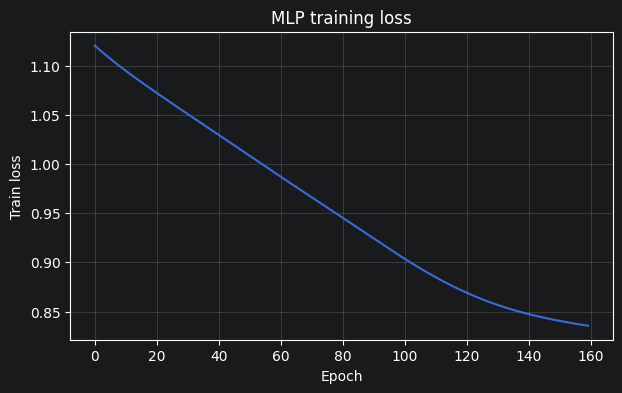

In [12]:
# TODO: побудуйте графік train_losses.

plt.figure(figsize=(7, 4))
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Train loss')
plt.title('MLP training loss')
plt.grid(alpha=0.3)
plt.show()

8. Оцінка якості
Порахуйте accuracy, weighted F1 і confusion matrix.

In [ ]:
def predict(model, X_tensor):
    model.eval()

    with torch.no_grad():
        # TODO: отримайте logits і predictions.
        logits = ...
        preds = ...
        pass

    # TODO: поверніть predictions як numpy array.
    return preds.cpu().numpy()


# TODO:
# 1. Отримайте y_pred через predict(model, X_test_tensor).
# 2. Підготуйте y_true з y_test_tensor.
# 3. Порахуйте accuracy, weighted F1 і confusion matrix.
# 4. Виведіть метрики.

# y_pred = ...
# y_true = ...
# accuracy = ...
# f1 = ...
# cm = ...

# print(f'Accuracy: {accuracy:.4f}')
# print(f'F1 score: {f1:.4f}')
# print(cm)